In [1]:
from pyprojroot import here
import sys
sys.path.insert(0, str(here()))

In [ ]:
from src.download_utils import load_download_bounds
from src.dem import save_reprojected_dem_from_file, merge_geotiffs_to_compressed_tif, plot_dem

In [ ]:
region, bounds = load_download_bounds()

In [ ]:
from dem_stitcher.stitcher import get_dem_tile_paths
import rasterio

In [ ]:
print(f"Building regional GLO-30 DEM for projection {region.epsg} (no stitch_dem path)...")

dem_root = here() / "data" / "digital_elevation_model"
tile_cache_dir = dem_root / "download" / "glo30_cache"
raw_merged_file = dem_root / "dem_30m_raw_wgs84.tif"

tile_cache_dir.mkdir(parents=True, exist_ok=True)

if raw_merged_file.exists() and raw_merged_file.stat().st_size > 0:
    print(f"Using existing raw mosaic: {raw_merged_file}")
else:
    print("Resolving and caching required GLO-30 tiles...")
    tile_paths = get_dem_tile_paths(
        bounds=bounds,
        dem_name='glo_30',
        localize_tiles_to_gtiff=True,
        n_threads_downloading=2,
        tile_dir=tile_cache_dir,
        overwrite_existing_tiles=False,
    )
    print(f"Tiles available for merge: {len(tile_paths)}")

    print("Merging cached tiles into one raw WGS84 DEM...")
    merge_geotiffs_to_compressed_tif(
        tile_paths,
        raw_merged_file,
        compress='zstd',
    )

print(f"Raw merged DEM ready: {raw_merged_file}")

Building regional GLO-30 DEM for projection EPSG:32645 (no stitch_dem path)...
Resolving and caching required GLO-30 tiles...


/home/admin/.miniforge3/envs/skyline_env/lib/python3.10/site-packages/dem_stitcher/stitcher.py:153: UserWarning: The directory/home/admin/SkylineGeolocation/data/digital_elevation_model/download/glo30_cache exists; We are writing new files to this directory
  warn(f'The directory{tile_dir} exists; We are writing new files to this directory', category=UserWarning)


Tiles available for merge: 120
Merging cached tiles into one raw WGS84 DEM...
Raw merged DEM ready: /home/admin/SkylineGeolocation/data/digital_elevation_model/dem_30m_raw_wgs84.tif


In [5]:
dem_file = here() / "data" / "digital_elevation_model" / "dem_30m.tif"
save_reprojected_dem_from_file(raw_merged_file, region, dem_file, resolution=30.0)

✓ Saved reprojected UTM DEM to: /home/admin/SkylineGeolocation/data/digital_elevation_model/dem_30m.tif


DEM Statistics (EPSG:32645):
 -> Minimum Elevation: -36.3 meters
 -> Maximum Elevation: 8736.7 meters
 -> Missing Data (NaN): 0.00%



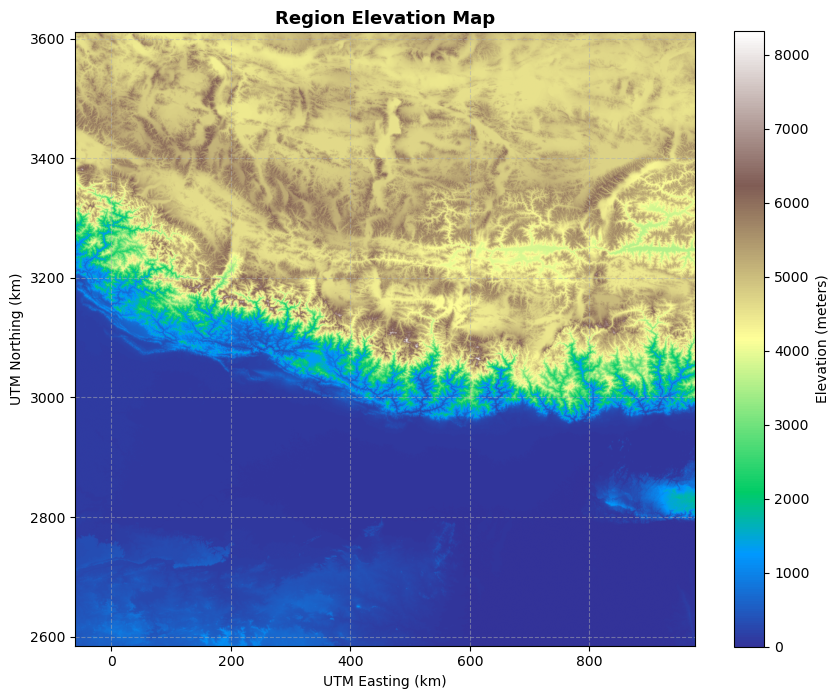

In [4]:
plot_dem(region,dem_file)